<a href="https://colab.research.google.com/github/sashamontgomery/Neur-265/blob/main/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Sasha Montgomery
<i>NEUR 265<i>

<b> April 3, 2026<b>

In [39]:
#importing relevant modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [40]:
#importing data sets
fear_traces = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv', delimiter = ',')
extinction_predictors = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv', delimiter = ',')
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',').astype(int)



In [41]:
#making conditioning and extinction traces
conditioning_traces = fear_traces[:10457]
extinction_traces = fear_traces[10457:,:]
#checking indexing correct
print(conditioning_traces.shape)
print(extinction_traces.shape)

(10457, 63)
(14211, 63)


In [42]:
#printing size of conditioning and extinction traces
print(conditioning_traces.size)
print(extinction_traces.size)

658791
895293


In [43]:
#making time conditioning and extinction variables
time_conditioning = np.linspace(1, (10457/15), 10457)
time_extinction = np.linspace(1, (14211/15), 14211)

63 ROIs (cells) were imaged during these sessions. The total length of time during the conditioning session was 697.2 seconds and 11.62 minutes. The total length of time during the extinction session was 947.3 seconds and 15.79 minutes.




Text(0.5, 1.0, 'Extinction Traces')

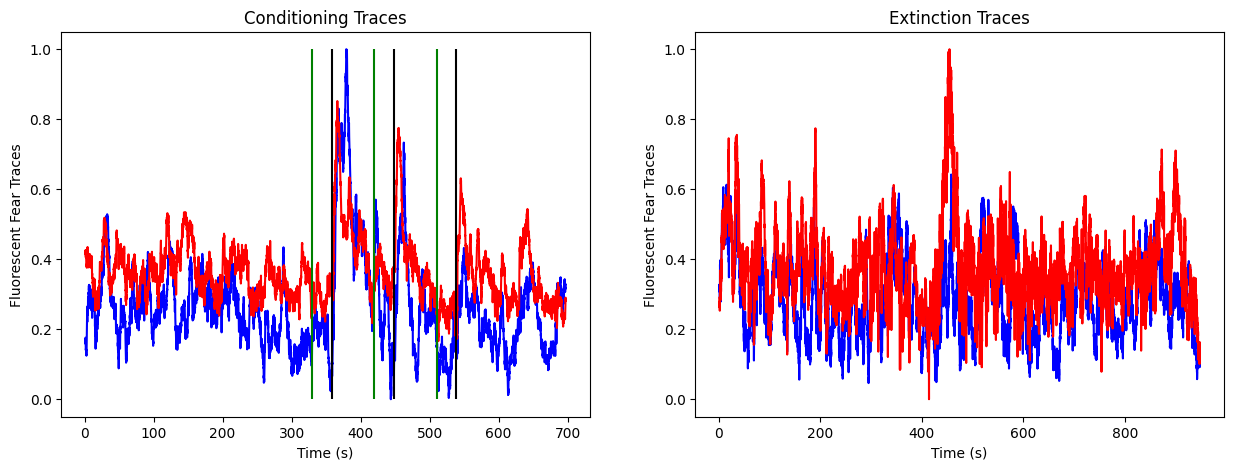

In [44]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(time_conditioning, conditioning_traces[:,0], color = 'blue')
ax[0].plot(time_conditioning, conditioning_traces[:,1], color = 'red')
ax[0].vlines(shock_index, 0, 1, color ='black')
ax[0].vlines(tone_index, 0, 1, color ='green')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Fluorescent Fear Traces')
ax[0].set_title('Conditioning Traces')

ax[1].plot(time_extinction, extinction_traces[:,0], color = 'blue')
ax[1].plot(time_extinction, extinction_traces[:,1], color = 'red')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Fluorescent Fear Traces')
ax[1].set_title('Extinction Traces')


There does seem to be a relationship between conditioning/extinction traces in first ROI and the second ROI. They seem to have mostly smilar patterns of activity, with the second ROI showing slightly higher fluorescent traces. There also appears to be a relationship between how a cell responds during conditioning and how it responds during extinction, with the patterns seen in conditioning appearing similar to the ones seen in extinction.

Using shock onset and tone onset as predictors in our model of the extinction session.
Correlating actual traces and predicted traces and comparing correlation coefficients.
This answers question: if a cell responds more strongly to shocks/tones during conditioning, does it also respond more strongly to tones during extinction?
Are the cells that encode the toneshock memory the same cells that form the extinction memory?

In [50]:
#making predictors_conditioning variable
shock_array = np.zeros(10457)
for i in range(10457):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10457)
for i in range(10457):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

from pandas import DataFrame as df

predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
predictors_conditioning['shock onset'] = shock_array


In [51]:
#making r_model conditioning variable and running for loop
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

predictors_conditioning['shock onset'] = shock_array
r_model_conditioning = np.zeros(63)

for i in range(63):
  trace_temp = conditioning_traces[:,i]
  model = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_conditioning[i] = r3.statistic


In [52]:
#making r_model extinction variable and running for loop
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

r_model_extinction = np.zeros(63)

for i in range(63):
  trace_temp = extinction_traces[:,i]
  model = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_extinction[i] = r3.statistic

In [53]:
#getting pearson r, correlating r model conditioning and r model extinction
pearsonr(r_model_conditioning, r_model_extinction)


PearsonRResult(statistic=np.float64(0.014141252464636184), pvalue=np.float64(0.9124089659017773))

Text(0, 0.5, 'r model extinction')

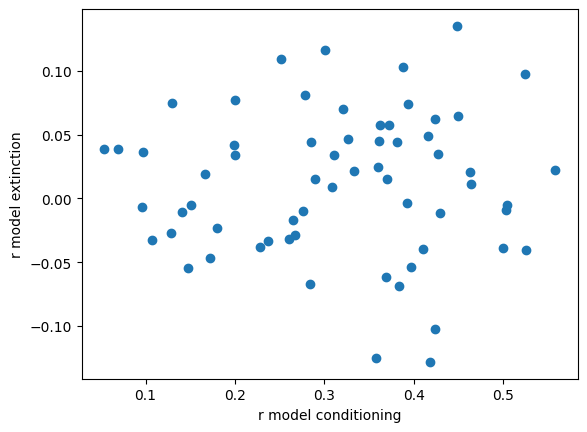

In [54]:
#making scatterplot to compare r model conditioning and r model extinction

plt.scatter(r_model_conditioning, r_model_extinction)
plt.xlabel('r model conditioning')
plt.ylabel('r model extinction')

There seems to be strong correlation between shock conditioning and shock extinction based on pearson r, which is less than 0.05. Furthermore, visually, there appears to be a positive correlation between conditioning response and extinction response of cells.